<a href="https://colab.research.google.com/github/jzazueta/data-science-business-econ/blob/main/notebooks/ch05_market_case_study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5 — Practical Case Study: Reading a Market from Raw Data

**Data Science for Business and Economics: A Python Approach**

This notebook mirrors every code example in Chapter 5. Sofía Alcántara, an analyst at Cardinal Point Advisory, is asked to read the U.S. specialty coffee retail market for a private equity client evaluating a platform investment.

Run the cells in order — later steps (e.g. the geography crosswalk in 5.7) depend on the `market` frame built earlier.

## 5.2 First Contact with the Data

### Code Example 5.1 — Loading the Raw Sources

In [5]:
import pandas as pd

stores = pd.read_csv("/data/coffee_store_locations.csv")
demographics = pd.read_csv("/data/county_demographics.csv")
consumer_spending = pd.read_csv("/data/macro_food_away_from_home_spending.csv")
price_index = pd.read_csv("/data/macro_food_away_from_home_cpi.csv")

for name, df in [
    ("stores", stores),
    ("demographics", demographics),
    ("consumer_spending", consumer_spending),
    ("price_index", price_index),
]:
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

stores: 4127 rows, 6 columns
demographics: 660 rows, 5 columns
consumer_spending: 36 rows, 2 columns
price_index: 36 rows, 2 columns


### Code Example 5.2 — A First Look at Each Table

In [6]:
stores.head()

,store_id,chain_name,county_fips,lat,lon,price_medium_cup
0,ST-100000,Other chains,28446,29.1288,-83.6125,3.58
1,ST-100001,Independent,24397,29.1108,-86.4478,4.13
2,ST-100002,Independent,45142,26.2044,-78.9813,3.52
3,ST-100003,Independent,49075,29.6416,-110.0643,5.61
4,ST-100004,Blue Ridge Roasters,21250,32.1047,-85.9484,3.86


One row is one store. `chain_name` carries either a named chain or the literal value `"Independent"`. `county_fips` is a FIPS code (Federal Information Processing Standard) — a numeric code the U.S. Census Bureau assigns to every state and county, used here as the join key against demographics.

**Try it yourself:** look at `demographics.head()` and the two macro tables. What granularity is each one at?

### Assembling a Single Frame

### Code Example 5.3 — Joining Stores to County Demographics

In [7]:
market = stores.merge(demographics, on="county_fips", how="left")

print(f"market: {market.shape[0]} rows, {market.shape[1]} columns")
print(f"unmatched counties: {market['median_household_income'].isna().sum()}")

market: 4127 rows, 10 columns
unmatched counties: 38


**Exercise:** re-run the merge with `how="inner"` instead of `how="left"`. How many rows does `market` have now? What happened to the 38 unmatched stores, and why might that matter for a market-sizing estimate?

## 5.3 Applying CSRVF, Compressed

### Code Example 5.4 — Characterizing Missingness and Implausible Values

In [8]:
print(market.isna().sum()[market.isna().sum() > 0])
print(f"\nzero-priced stores: {(market['price_medium_cup'] == 0).sum()}")

median_household_income    38
median_age                 38
population                 38
avg_household_size         38
dtype: int64

zero-priced stores: 61


### Code Example 5.5 — Recoding Implausible Zeros

In [9]:
import numpy as np

market["price_medium_cup"] = market["price_medium_cup"].replace(0, np.nan)
print(f"missing prices after recoding: {market['price_medium_cup'].isna().sum()}")

missing prices after recoding: 61


### Code Example 5.6 — Distribution of Price

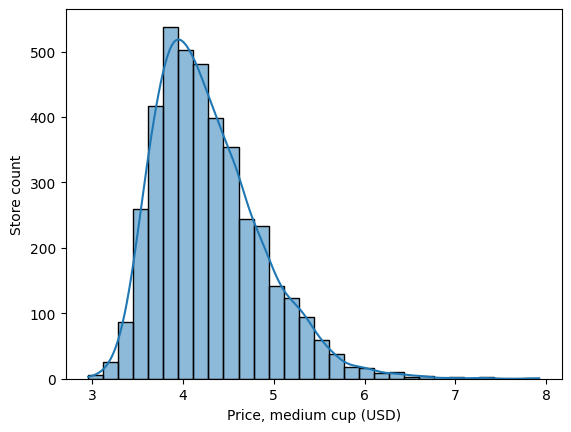

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=market, x="price_medium_cup", bins=30, kde=True)
plt.xlabel("Price, medium cup (USD)")
plt.ylabel("Store count")
plt.show()

`chain_name` value counts show independents holding a large share of the market — worth checking before moving on.

In [11]:
market["chain_name"].value_counts(normalize=True).mul(100).round(1)

,proportion
chain_name,
Independent,39.3
Other chains,27.0
Blue Ridge Roasters,17.7
Cardinal Coffee Co.,16.0


### Code Example 5.7 — Deriving Census Geography from the FIPS Code

A real store-locator scrape returns coordinates and a FIPS code, not a census label. Build the region/division fields from a small reference crosswalk keyed on the state code (the first two digits of `county_fips`).

In [13]:
crosswalk = pd.read_csv("/data/fips_region_crosswalk.csv", dtype={"state_fips": str})

market["state_fips"] = market["county_fips"].astype(str).str.zfill(5).str[:2]
market = market.merge(crosswalk, on="state_fips", how="left")
market["is_independent"] = market["chain_name"] == "Independent"

market[["county_fips", "state_fips", "census_region", "census_division"]].head()

,county_fips,state_fips,census_region,census_division
0,28446,28,South,East South Central
1,24397,24,South,South Atlantic
2,45142,45,South,South Atlantic
3,49075,49,West,Mountain
4,21250,21,South,East South Central


### Code Example 5.8 — Choosing a Geographic Grouping by Variance Explained

In [14]:
def variance_explained(df, group_col, value_col):
    df = df.dropna(subset=[value_col])
    overall_mean = df[value_col].mean()
    ss_total = ((df[value_col] - overall_mean) ** 2).sum()
    group_means = df.groupby(group_col)[value_col].transform("mean")
    ss_between = ((group_means - overall_mean) ** 2).sum()
    return ss_between / ss_total

for grouping in ["census_region", "census_division", "state_fips"]:
    ratio = variance_explained(market, grouping, "price_medium_cup")
    n_groups = market[grouping].nunique()
    print(f"{grouping:15s} ({n_groups:3d} groups): variance explained = {ratio:.3f}")

census_region   (  4 groups): variance explained = 0.147
census_division (  9 groups): variance explained = 0.171
state_fips      ( 49 groups): variance explained = 0.192


Four regions explain about 14.7% of the variance in price; nine divisions push that to about 17.1%; forty-nine states push it further to about 19.2%. The state-level number looks best on its face, but state-level store counts are uneven (a few dozen to over a hundred), and an unadjusted variance-explained ratio tends to creep upward as group count rises even under pure noise. This is exactly what a formal ANOVA $F$-test corrects for by weighing the gain against the number of groups.

**Exercise:** compute the average number of stores per state. Which states have the fewest? Does that change how much you'd trust the state-level number?

### Code Example 5.9 — Price by Region and Store Type

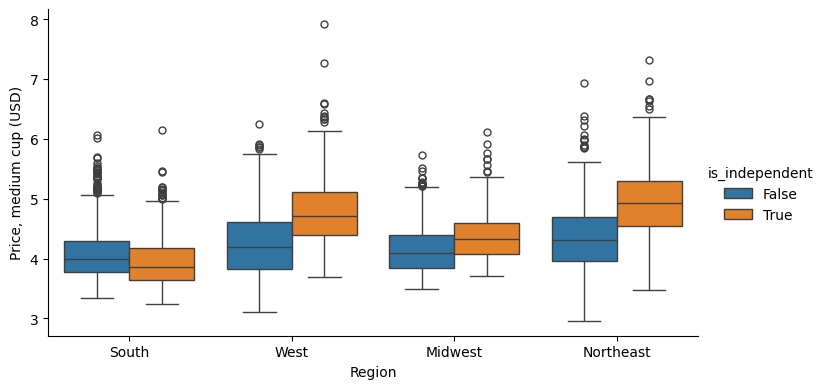

In [15]:
sns.catplot(
    data=market,
    x="census_region",
    y="price_medium_cup",
    hue="is_independent",
    kind="box",
    height=4,
    aspect=1.8,
)
plt.xlabel("Region")
plt.ylabel("Price, medium cup (USD)")
plt.show()

### Code Example 5.10 — Constructing Two Derived Features

In [16]:
market["price_premium"] = market.groupby("census_region")["price_medium_cup"].transform(
    lambda x: x / x.median()
)
market["income_per_capita"] = market["median_household_income"] / market["avg_household_size"]

market[["census_region", "price_medium_cup", "price_premium", "income_per_capita"]].head()

,census_region,price_medium_cup,price_premium,income_per_capita
0,South,3.58,0.906329,20000.000000
1,South,4.13,1.045570,23433.962264
2,South,3.52,0.891139,19892.857143
3,West,5.61,1.273553,45846.153846
4,South,3.86,0.977215,20120.481928


## 5.4 From Observations to a Story

### Code Example 5.11 — Connecting Price Premium to Local Income

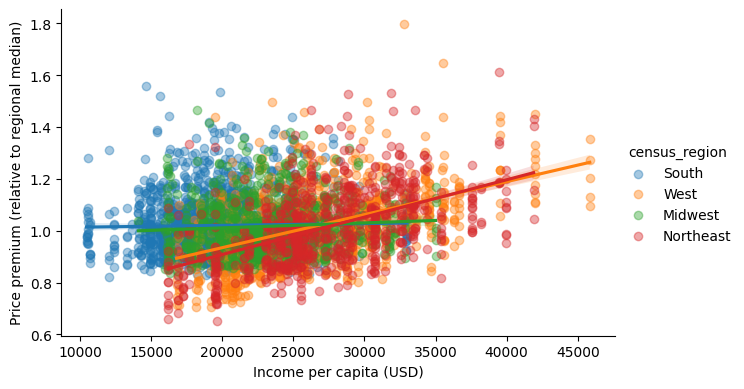

In [17]:
sns.lmplot(
    data=market,
    x="income_per_capita",
    y="price_premium",
    hue="census_region",
    height=4,
    aspect=1.6,
    scatter_kws={"alpha": 0.4},
)
plt.xlabel("Income per capita (USD)")
plt.ylabel("Price premium (relative to regional median)")
plt.show()

**Exercise:** compute the correlation between `price_premium` and `income_per_capita` separately for each region (hint: `groupby("census_region").apply(...)` with `.corr()`). Which regions show the strongest relationship? Does that match what the scatter plot suggests visually?

### Code Example 5.12 — A Quick Macro Check

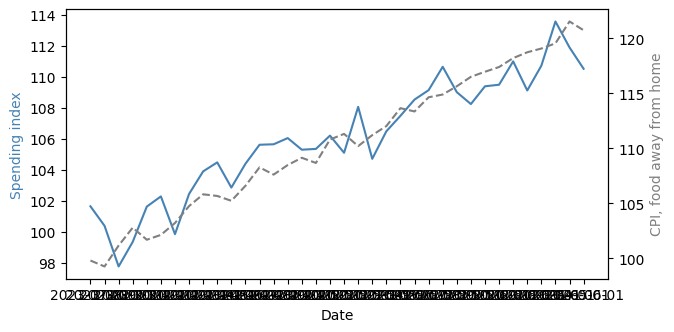

In [18]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax2 = ax.twinx()

ax.plot(consumer_spending["date"], consumer_spending["spending_index"], color="steelblue")
ax2.plot(price_index["date"], price_index["cpi_food_away"], color="gray", linestyle="--")

ax.set_xlabel("Date")
ax.set_ylabel("Spending index", color="steelblue")
ax2.set_ylabel("CPI, food away from home", color="gray")
plt.show()

## 5.5 Choosing the Visual Language

### Code Example 5.13 — The Fragmentation Figure

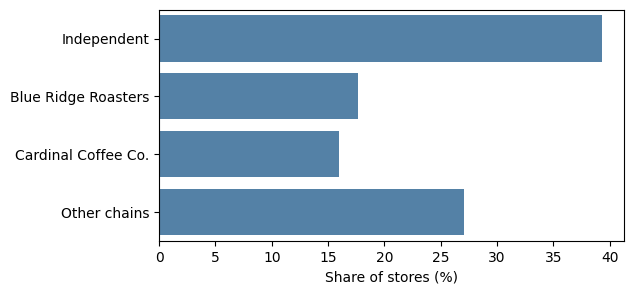

In [19]:
share = market["chain_name"].value_counts(normalize=True).mul(100)
named = share.drop("Other chains").sort_values(ascending=False)
share = pd.concat([named, share.loc[["Other chains"]]])

fig, ax = plt.subplots(figsize=(6, 3))
sns.barplot(x=share.values, y=share.index, color="#4682B4", ax=ax)
ax.set_xlabel("Share of stores (%)")
ax.set_ylabel("")
plt.show()

### Code Example 5.14 — Simplified Regional Comparison

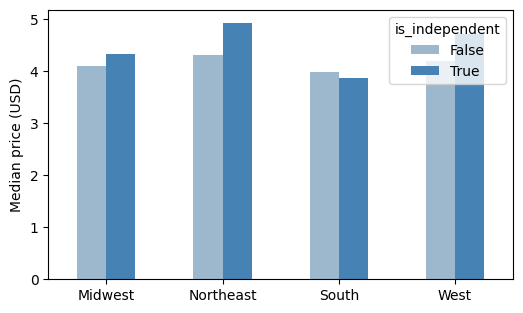

In [20]:
region_summary = (
    market.groupby(["census_region", "is_independent"])["price_medium_cup"]
    .median()
    .unstack()
)

region_summary.plot(kind="bar", figsize=(6, 3.5), color=["#9db8cc", "#4682B4"])
plt.xlabel("")
plt.ylabel("Median price (USD)")
plt.xticks(rotation=0)
plt.show()

## Exercise 5.1 — Write the Brief

Using only the three figures above (fragmentation, regional comparison, price premium vs. income), write a three-paragraph market brief in Sofia's voice, addressed to the PE client, ending with a one-sentence recommendation. Aim for something a partner could read in under four minutes.

## Exercise 5.2 — What Would Change

Suppose the South showed the same independent price premium as the Northeast, instead of an inverted one. How would that change the brief's recommendation? Which figure would need to change, and how?

## Exercise 5.3 — A Different Grouping

The variance-explained check in Code Example 5.8 compared region, division, and state. Try `county_fips` itself as a grouping (the finest level available). What happens to the variance-explained ratio, and why is that number almost meaningless here?